# WRAPIFY.ipynb
### Wrapify will take your Spotify data and give you many of the same metrics that you can expect to receive from a typical Spotify Wrapped. This is a passion project that I am still actively working on, but all basic functions have been completed! The following functionality will hopefully be added in the future:

#### search for a specific song for the following results:
- how many listens you had all time
- How many listens did you have each year, with a visual graph
- How many times have you skipped each year + graph
- How many times have you skipped all time

#### search for a specific artist for the following results:
- how many listens you had all time
- How many listens did you have each year, with a visual graph
- How many individual songs have you listened to by them
- a graph showing which songs got replayed the most
- How many times have you skipped each year + graph
- How many times have you skipped all time

#### What genre is most popular with the user?
- include visuals to show which genres are most listened to
- if possible, list a song's genre alongside its artist and album
- if possible, list an artist's genre

In [1]:
import os
import json
import pandas as pd
from collections import Counter
import seaborn as sns
import io

# for data visualizations
sns.set_theme()
sns.set_palette("deep")

folder = 'Spotify Extended Streaming History'  # folder containing JSON files
#---------------------------------------------------------------------------------
# The following code is meant to load a series of JSON files from one folder, 
# concatenate them all together, remove rows with null values, and save them as 
# an entirely new csv file that can then be used for data queries.
#---------------------------------------------------------------------------------
def merge_json_files(folder):
    merged_data = pd.DataFrame()

    # ensure folder exists
    if not os.path.isdir(folder):
        print(f"Error: Folder '{folder}' not found.")
        return

    # iterate through all files in the folder
    for filename in os.listdir(folder):
        if filename.endswith('.json'): # ensure it ends in .json
            filepath = os.path.join(folder, filename)
            with open(filepath, encoding='utf-8') as f:
                data = pd.read_json(f)
                merged_data = pd.concat([merged_data, data], ignore_index=True)               
                cleaned_data = merged_data.dropna(subset=['master_metadata_track_name']) #remove any rows without a track name
                keys_to_remove = ["platform", "conn_country", "ip_addr", "episode_name", "episode_show_name", 
                       "spotify_episode_uri","audiobook_title", "audiobook_uri", "audiobook_chapter_uri", 
                       "audiobook_chapter_title", "incognito_mode", "offline_timestamp"]
                for key in keys_to_remove:
                    cleaned_data.pop(key) #get rid of all these keys

                # renaming columns for better readability
                cleaned_data = cleaned_data.rename(columns={ 
                    'master_metadata_track_name': 'song_title',
                    'master_metadata_album_artist_name': 'artist_name',
                    'master_metadata_album_album_name': 'album_name',
                    'spotify_track_uri': 'track_url'})

                # Keeps rows where ms_played is between 20000 and 900000
                # songs outside of this range don't make much sense
                cleaned_data = cleaned_data[cleaned_data['ms_played'].between(20000, 900000)]

                # remove the $ from variables since it gets misread by the parser
                cleaned_data['song_title'] = cleaned_data['song_title'].astype(str).str.replace('$', 'S', regex=False)
                cleaned_data['album_name'] = cleaned_data['album_name'].astype(str).str.replace('$', 'S', regex=False)
                cleaned_data['artist_name'] = cleaned_data['artist_name'].astype(str).str.replace('$', 'S', regex=False)

    # remove null values and save merged DataFrame to JSON file (pretty formatted)
    cleaned_data.to_csv('streaming_history.csv', index=False)
    print(f"Merged {len(cleaned_data)} total rows from {folder}/")

# run the function
merge_json_files(folder)

Merged 65545 total rows from Spotify Extended Streaming History/


# Top 20 tracks and artists

In [2]:
#---------------------------------------------------------------------------------
# The following code will produce my top 20 most listened to songs and artists of all time
#---------------------------------------------------------------------------------
with open('streaming_history.csv', encoding='utf-8') as f:
    data = pd.read_csv(f)

    top_tracks_summary = (
        data.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(20)
    )
    
    top_artists_summary = (
        data.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(20)
    )
    
    total_ms_played = data['ms_played'].sum()
    total_minutes = (total_ms_played / 1000) / 60
    total_minutes = total_minutes.astype(int)
    total_hours = total_minutes / 60
    total_hours = total_hours.astype(int)

## Total time listened for all time

In [3]:
print(
    "==================================================================\n"
    "You've enjoyed music for a total of", total_minutes, "minutes, or", total_hours, "hours.\n"
    "=================================================================="
)

You've enjoyed music for a total of 204330 minutes, or 3405 hours.


## Top 20 songs

,song_title,album_name,play_count,artist
0,Stand By You,Wildfire,171,Rachel Platten
1,The Sound of Silence,Immortalized,137,Disturbed
2,Chocolate,The 1975,133,The 1975
3,Starlight,Black Holes and Revelations,128,Muse
4,Revolt,Drones,127,Muse
5,The Only Hope for Me Is You,Danger Days: The True Lives of the Fabulous Ki...,116,My Chemical Romance
6,Undertale (Music Box),Undertale (Music Box),114,Jayn
7,United States of Eurasia (+Collateral Damage),The Resistance,113,Muse
8,Monkey Tree - UK Mix,Very Good Bad Thing,112,Mother Mother
9,High School,Darling,110,SayWeCanFly


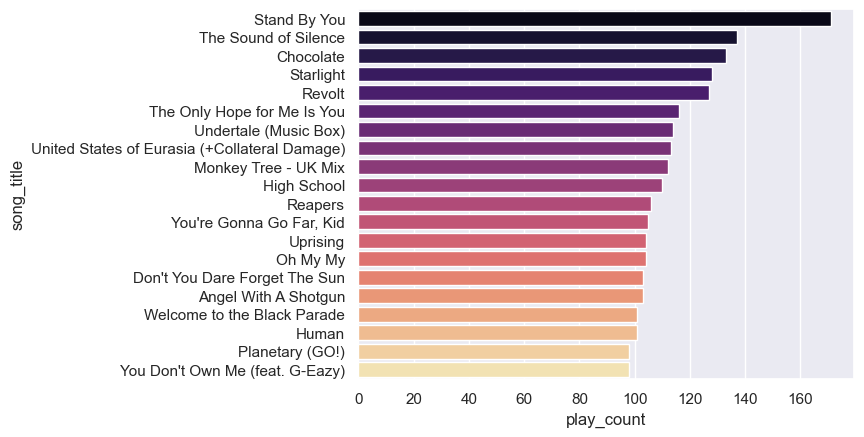

In [4]:
# print a bar plot including the top 20 tracks of all time
sns.barplot(x="play_count", y="song_title", data=top_tracks_summary,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 20 tracks of all time
top_tracks_summary_anagram = top_tracks_summary.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_summary_anagram.head(20)

## Top 20 artists

,artist_name,play count
0,Muse,3014
1,Twenty One Pilots,2156
2,One Direction,1749
3,My Chemical Romance,1485
4,Panic! At The Disco,1449
5,Imagine Dragons,1414
6,Ghost,1397
7,Bleachers,955
8,Halsey,884
9,Lorde,810


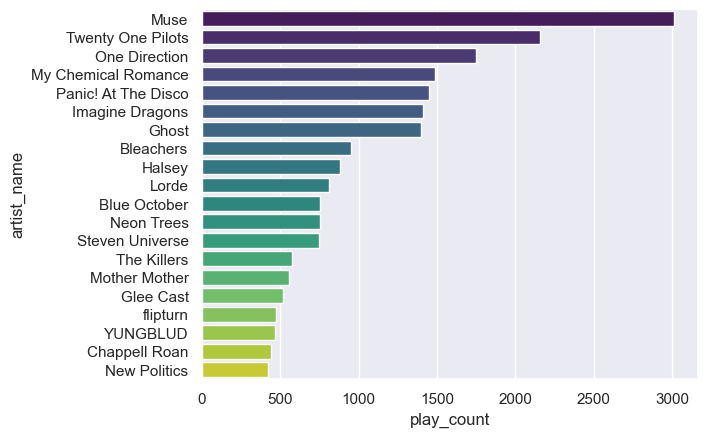

In [5]:
# print a bar plot including the top 20 tracks of all time
sns.barplot(x="play_count", y="artist_name", data=top_artists_summary,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 20 tracks of all time
top_artists_summary_anagram = top_artists_summary.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_summary_anagram.head(20)

## Listening trends by year

In [38]:
#---------------------------------------------------------------------------------
# The following code will produce my top 10 most listened to songs of each year
#---------------------------------------------------------------------------------
with open('streaming_history.csv', encoding='utf-8') as f:
    data = pd.read_csv(f)

    # dataset for 2016 listening patterns
    data_2016 = data[data['ts'].between('2016-01-00T00:00:00Z', '2016-12-31T23:59:59Z')]
    top_tracks_2016 = (
        data_2016.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2016 = (
        data_2016.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2016 = data_2016['ms_played'].sum()
    minutes_2016 = (ms_played_2016 / 1000) / 60
    minutes_2016 = minutes_2016.astype(int)
    hours_2016 = minutes_2016 / 60
    hours_2016 = hours_2016.astype(int)

    # dataset for 2017 listening patterns
    data_2017 = data[data['ts'].between('2017-01-00T00:00:00Z', '2017-12-31T23:59:59Z')]
    top_tracks_2017 = (
        data_2017.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2017 = (
        data_2017.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2017 = data_2017['ms_played'].sum()
    minutes_2017 = (ms_played_2017 / 1000) / 60
    minutes_2017 = minutes_2017.astype(int)
    hours_2017 = minutes_2017 / 60
    hours_2017 = hours_2017.astype(int)

    # dataset for 2018 listening patterns
    data_2018 = data[data['ts'].between('2018-01-00T00:00:00Z', '2018-12-31T23:59:59Z')]
    top_tracks_2018 = (
        data_2018.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2018 = (
        data_2018.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2018 = data_2018['ms_played'].sum()
    minutes_2018 = (ms_played_2018 / 1000) / 60
    minutes_2018 = minutes_2018.astype(int)
    hours_2018 = minutes_2018 / 60
    hours_2018 = hours_2018.astype(int)

    # dataset for 2019 listening patterns
    data_2019 = data[data['ts'].between('2019-01-00T00:00:00Z', '2019-12-31T23:59:59Z')]
    top_tracks_2019 = (
        data_2019.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2019 = (
        data_2019.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2019 = data_2019['ms_played'].sum()
    minutes_2019 = (ms_played_2019 / 1000) / 60
    minutes_2019 = minutes_2019.astype(int)
    hours_2019 = minutes_2019 / 60
    hours_2019 = hours_2019.astype(int)

    # dataset for 2020 listening patterns
    data_2020 = data[data['ts'].between('2020-01-00T00:00:00Z', '2020-12-31T23:59:59Z')]
    top_tracks_2020 = (
        data_2020.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2020 = (
        data_2020.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2020 = data_2020['ms_played'].sum()
    minutes_2020 = (ms_played_2020 / 1000) / 60
    minutes_2020 = minutes_2020.astype(int)
    hours_2020 = minutes_2020 / 60
    hours_2020 = hours_2020.astype(int)

    # dataset for 2021 listening patterns
    data_2021 = data[data['ts'].between('2021-01-00T00:00:00Z', '2021-12-31T23:59:59Z')]
    top_tracks_2021 = (
        data_2021.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2021 = (
        data_2021.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2021 = data_2021['ms_played'].sum()
    minutes_2021 = (ms_played_2021 / 1000) / 60
    minutes_2021 = minutes_2021.astype(int)
    hours_2021 = minutes_2021 / 60
    hours_2021 = hours_2021.astype(int)

    # dataset for 2022 listening patterns
    data_2022 = data[data['ts'].between('2022-01-00T00:00:00Z', '2022-12-31T23:59:59Z')]
    top_tracks_2022 = (
        data_2022.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2022 = (
        data_2022.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2022 = data_2022['ms_played'].sum()
    minutes_2022 = (ms_played_2022 / 1000) / 60
    minutes_2022 = minutes_2022.astype(int)
    hours_2022 = minutes_2022 / 60
    hours_2022 = hours_2022.astype(int)

    # dataset for 2023 listening patterns
    data_2023 = data[data['ts'].between('2023-01-00T00:00:00Z', '2023-12-31T23:59:59Z')]
    top_tracks_2023 = (
        data_2023.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2023 = (
        data_2023.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2023 = data_2023['ms_played'].sum()
    minutes_2023 = (ms_played_2023 / 1000) / 60
    minutes_2023 = minutes_2023.astype(int)
    hours_2023 = minutes_2023 / 60
    hours_2023 = hours_2023.astype(int)

    # dataset for 2024 listening patterns
    data_2024 = data[data['ts'].between('2024-01-00T00:00:00Z', '2024-12-31T23:59:59Z')]
    top_tracks_2024 = (
        data_2024.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )
    
    top_artists_2024 = (
        data_2024.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2024 = data_2024['ms_played'].sum()
    minutes_2024 = (ms_played_2024 / 1000) / 60
    minutes_2024 = minutes_2024.astype(int)
    hours_2024 = minutes_2024 / 60
    hours_2024 = hours_2024.astype(int)

    # dataset for 2025 listening patterns
    data_2025 = data[data['ts'].between('2025-01-00T00:00:00Z', '2025-12-31T23:59:59Z')]
    top_tracks_2025 = (
        data_2025.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2025 = (
        data_2025.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    ms_played_2025 = data_2025['ms_played'].sum()
    minutes_2025 = (ms_played_2025 / 1000) / 60
    minutes_2025 = minutes_2025.astype(int)
    hours_2025 = minutes_2025 / 60
    hours_2025 = hours_2025.astype(int)

## Total Hours Listened by Year

<Axes: xlabel='year', ylabel='hours'>

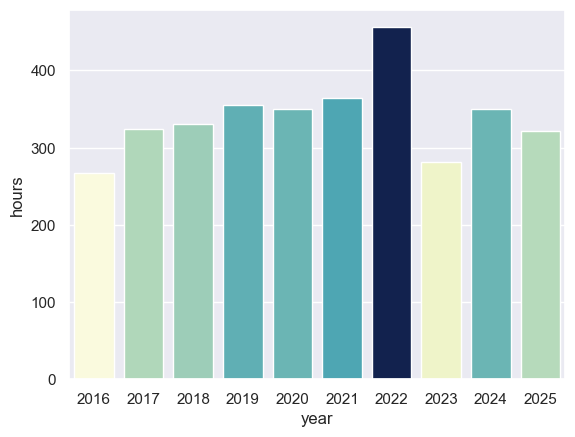

In [7]:
ms_by_year = {
    'year': ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
    'hours': [hours_2016, hours_2017, hours_2018, hours_2019, hours_2020, hours_2021, hours_2022, hours_2023, hours_2024, hours_2025]
    }
ms_df = pd.DataFrame(ms_by_year)
sns.barplot(x="year", y="hours", data=ms_df,
            label="Total", palette="YlGnBu", hue="hours", legend=False)

## 2016

In [8]:
print(
    "======================================================================\n"
    "In 2016, you've enjoyed music for a total of", minutes_2016, "minutes, or", hours_2016, "hours.\n"
    "======================================================================"
)

In 2016, you've enjoyed music for a total of 16050 minutes, or 267 hours.


,song_title,album_name,play_count,artist
0,Stand By You,Wildfire,171,Rachel Platten
1,The Sound of Silence,Immortalized,100,Disturbed
2,Angel With A Shotgun,Symphony Soldier,74,The Cab
3,Undertale (Music Box),Undertale (Music Box),64,Jayn
4,Heathens,Heathens,59,Twenty One Pilots
5,CHARIOTS OF FIRE - Café Buddha Del Mar Bar Mix...,Lounge Of Love,56,Eternal-Flame
6,"You're Gonna Go Far, Kid","Rise And Fall, Rage And Grace",53,The Offspring
7,High School,Darling,51,SayWeCanFly
8,Metal Crusher (Undertale) [Piano Version],UNDERTALE (Piano Selections),49,Game Soundtrack Cat
9,Hopes and Dreams ~ SAVE the World,Undertale Symphonic Metal,47,Ferdk


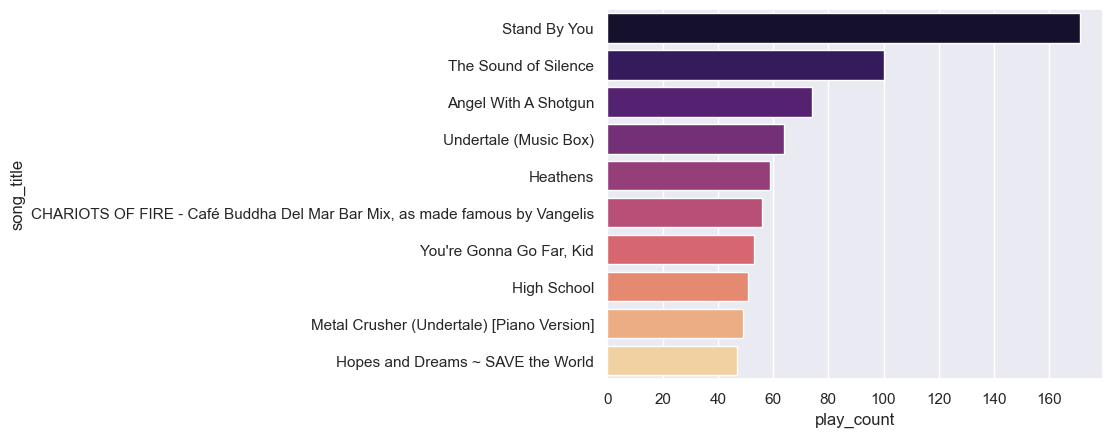

In [9]:
# print a bar plot including the top 10 tracks of 2016
sns.barplot(x="play_count", y="song_title", data=top_tracks_2016,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2016
top_tracks_2016_anagram = top_tracks_2016.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2016_anagram.head(10)

,artist_name,play count
0,Twenty One Pilots,892
1,Panic! At The Disco,462
2,Imagine Dragons,284
3,Halsey,216
4,Rachel Platten,171
5,Ferdk,112
6,Disturbed,100
7,Daya,93
8,Holder,85
9,Nate Ruess,76


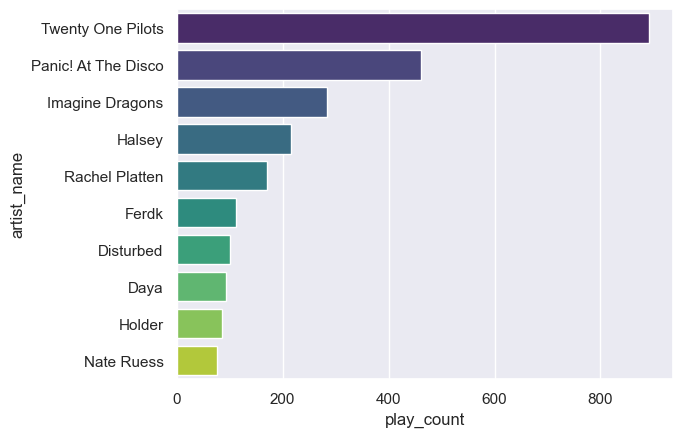

In [10]:
# print a bar plot including the top 10 artists of 2016
sns.barplot(x="play_count", y="artist_name", data=top_artists_2016,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2016
top_artists_2016_anagram = top_artists_2016.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2016_anagram.head(10)

## 2017

In [11]:
print(
    "======================================================================\n"
    "In 2017, you've enjoyed music for a total of", minutes_2017, "minutes, or", hours_2017, "hours.\n"
    "======================================================================"
)

In 2017, you've enjoyed music for a total of 19455 minutes, or 324 hours.


,song_title,album_name,play_count,artist
0,I Dreamed A Dream (Glee Cast Version) (feat. I...,"Glee: The Music, Volume 3 Showstoppers",54,Glee Cast
1,You Don't Own Me (feat. G-Eazy),FMA,42,SAYGRACE
2,I'm Ready,Living Room,34,AJR
3,True Love,The Truth About Love,34,P!nk
4,Feeling Good,It's Time,33,Michael Bublé
5,Copacabana (Glee Cast Version),Copacabana (Glee Cast Version),33,Glee Cast
6,Total Eclipse Of The Heart (Glee Cast Version)...,"Glee: The Music, Volume 3 Showstoppers",31,Glee Cast
7,Without Me,The Eminem Show,30,Eminem
8,BOSS,Reflection,30,Fifth Harmony
9,Thunder,Evolve,29,Imagine Dragons


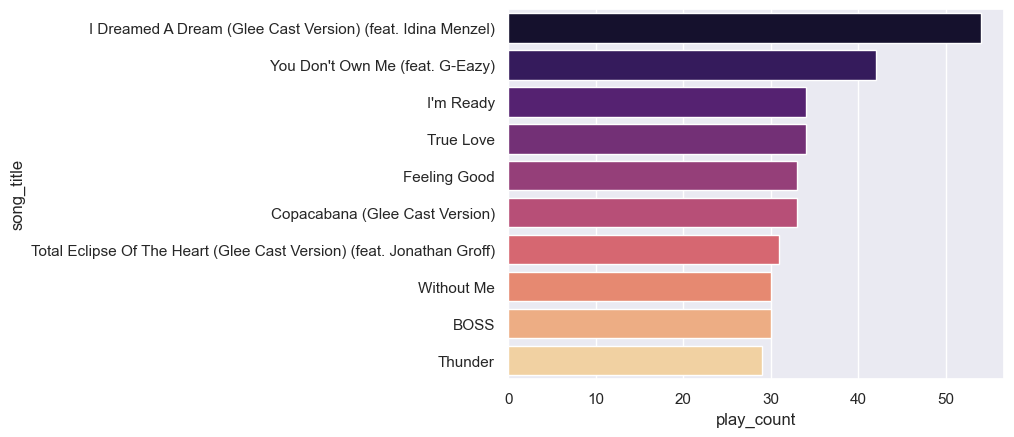

In [12]:
# print a bar plot including the top 10 tracks of 2017
sns.barplot(x="play_count", y="song_title", data=top_tracks_2017,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2017
top_tracks_2017_anagram = top_tracks_2017.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2017_anagram.head(10)

,artist_name,play count
0,Imagine Dragons,616
1,Twenty One Pilots,507
2,Steven Universe,406
3,Halsey,335
4,Panic! At The Disco,244
5,Glee Cast,198
6,Leslie Odom Jr.,70
7,Hailee Steinfeld,62
8,Ben Platt,61
9,Ed Sheeran,57


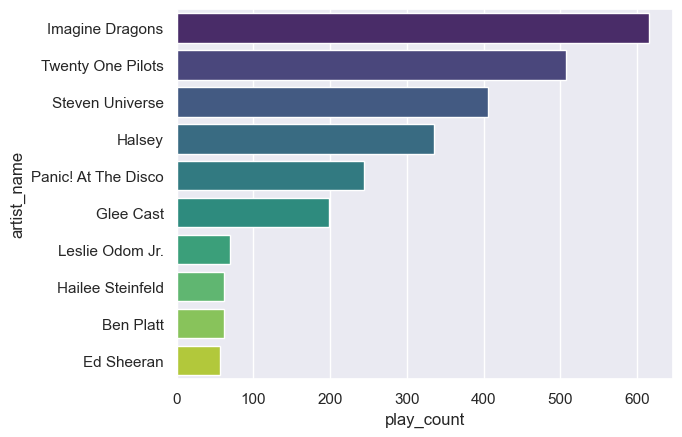

In [13]:
# print a bar plot including the top 10 artists of 2017
sns.barplot(x="play_count", y="artist_name", data=top_artists_2017,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2017
top_artists_2017_anagram = top_artists_2017.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2017_anagram.head(10)

## 2018

In [14]:
print(
    "======================================================================\n"
    "In 2018, you've enjoyed music for a total of", minutes_2018, "minutes, or", hours_2018, "hours.\n"
    "======================================================================"
)

In 2018, you've enjoyed music for a total of 19912 minutes, or 331 hours.


,song_title,album_name,play_count,artist
0,Da Ya Think I'm Sexy,Da Ya Think I'm Sexy?,43,Rod Stewart
1,Panic Room,Panic Room,41,Au/Ra
2,Never Enough,The Greatest Showman (Original Motion Picture ...,40,Loren Allred
3,Everybody Wants To Rule The World,Songs From The Big Chair,37,Tears For Fears
4,"Golden Slumbers / Carry That Weight - From ""Si...",Sing - Original Motion Picture Soundtrack / De...,36,Jennifer Hudson
5,The Love Club,Pure Heroine,33,Lorde
6,Old Fashioned,Pray for the Wicked,32,Panic! At The Disco
7,This Is Me,The Greatest Showman (Original Motion Picture ...,32,Keala Settle
8,Monkey Tree - UK Mix,Very Good Bad Thing,31,Mother Mother
9,War!,War!,30,Zach Callison


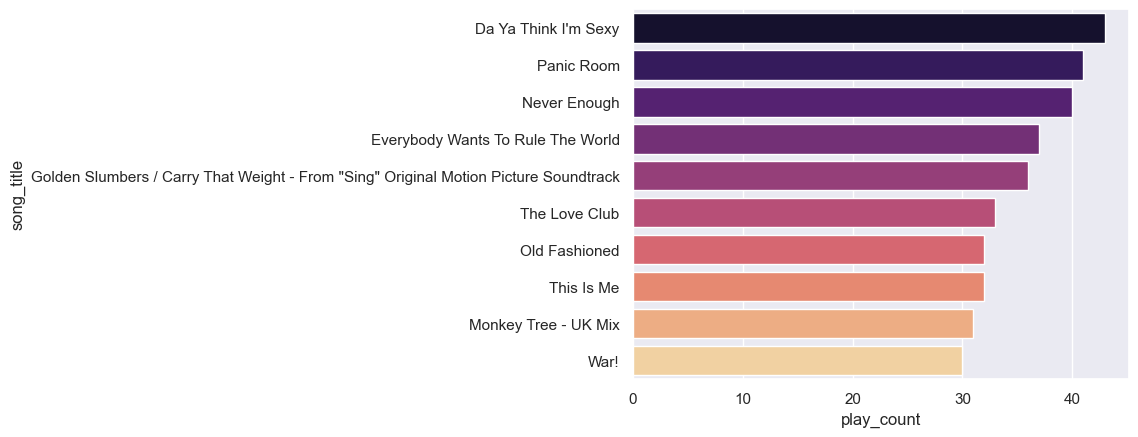

In [15]:
# print a bar plot including the top 10 tracks of 2018
sns.barplot(x="play_count", y="song_title", data=top_tracks_2018,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2018
top_tracks_2018_anagram = top_tracks_2018.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2018_anagram.head(10)

,artist_name,play count
0,Panic! At The Disco,386
1,Twenty One Pilots,381
2,Lorde,348
3,Imagine Dragons,236
4,Original Broadway Cast of Hamilton,232
5,Steven Universe,203
6,John Powell,149
7,Halsey,128
8,Zach Callison,116
9,Lin-Manuel Miranda,113


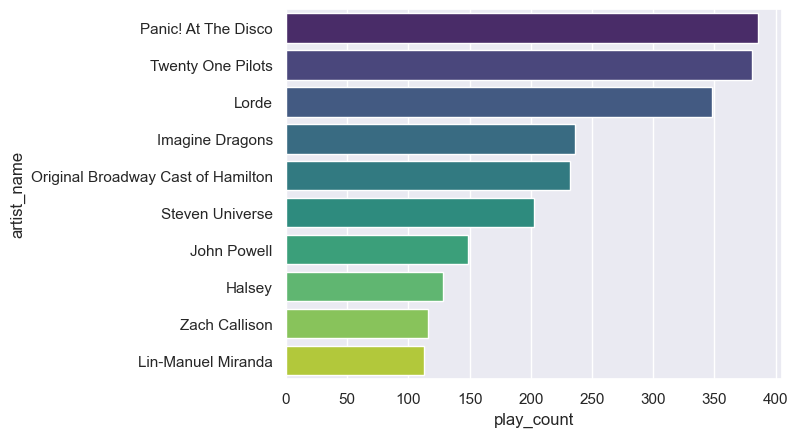

In [39]:
# print a bar plot including the top 10 artists of 2018
sns.barplot(x="play_count", y="artist_name", data=top_artists_2018,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2018
top_artists_2018_anagram = top_artists_2018.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2018_anagram.head(10)

## 2019

In [17]:
print(
    "======================================================================\n"
    "In 2019, you've enjoyed music for a total of", minutes_2019, "minutes, or", hours_2019, "hours.\n"
    "======================================================================"
)

In 2019, you've enjoyed music for a total of 21357 minutes, or 355 hours.


,song_title,album_name,play_count,artist
0,Kissaphobic,Visions of Hollywood,37,Make Out Monday
1,Private Fears in Public Places,Aware,37,Front Porch Step
2,Promise Me,A Good Friend Is Nice,34,Jack & Jack
3,Lethal Combination,Beautiful People Will Ruin Your Life,34,The Wombats
4,The Only Hope for Me Is You,Danger Days: The True Lives of the Fabulous Ki...,33,My Chemical Romance
5,Monkey Tree - UK Mix,Very Good Bad Thing,32,Mother Mother
6,Girls Like Girls,This Side of Paradise,31,Hayley Kiyoko
7,And There You Are,And There You Are,31,Alex Walker Smith
8,Freaks,Freaks,31,Jordan Clarke
9,Dusk Till Dawn (feat. Sia) - Radio Edit,Dusk Till Dawn (feat. Sia),30,ZAYN


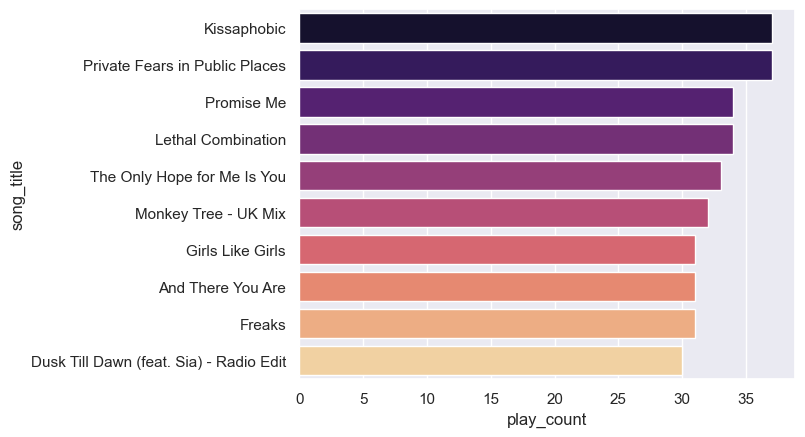

In [18]:
# print a bar plot including the top 10 tracks of 2019
sns.barplot(x="play_count", y="song_title", data=top_tracks_2019,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2019
top_tracks_2019_anagram = top_tracks_2019.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2019_anagram.head(10)

,artist_name,play count
0,One Direction,636
1,Bleachers,235
2,YUNGBLUD,197
3,Twenty One Pilots,172
4,Jack & Jack,134
5,My Chemical Romance,125
6,Steven Universe,124
7,Lorde,112
8,Panic! At The Disco,109
9,Billie Eilish,97


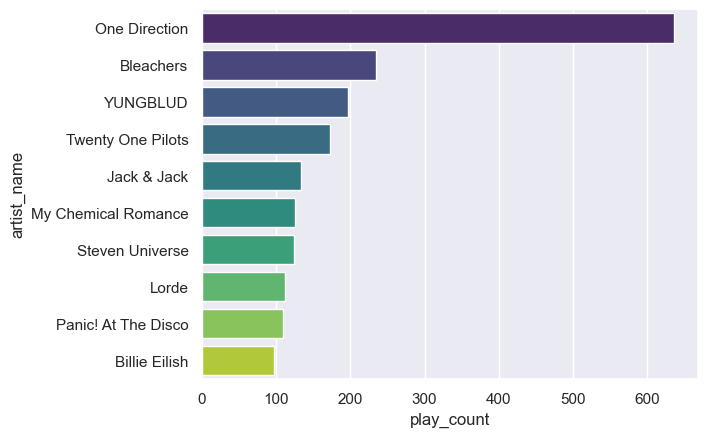

In [19]:
# print a bar plot including the top 10 artists of 2019
sns.barplot(x="play_count", y="artist_name", data=top_artists_2019,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2019
top_artists_2019_anagram = top_artists_2019.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2019_anagram.head(10)

## 2020

In [20]:
print(
    "======================================================================\n"
    "In 2020, you've enjoyed music for a total of", minutes_2020, "minutes, or", hours_2020, "hours.\n"
    "======================================================================"
)

In 2020, you've enjoyed music for a total of 21057 minutes, or 350 hours.


,song_title,album_name,play_count,artist
0,Therapy,An Invitation to an Alternate Reality,47,New Politics
1,Human,Day & Age - Bonus Tracks,46,The Killers
2,Breakup Haircut,Breakup Haircut,44,Danny and Alex
3,Sisters,The Original Motion Picture Soundtrack: Pt. 1,43,Saint Motel
4,Starlight,Black Holes and Revelations,42,Muse
5,Goodbye Copenhagen,A Bad Girl In Harlem,40,New Politics
6,Girl Crush,Vikings,40,New Politics
7,United States of Eurasia (+Collateral Damage),The Resistance,40,Muse
8,Cold Cold Man,My Type EP,38,Saint Motel
9,Cemetery,Dreamland,37,COIN


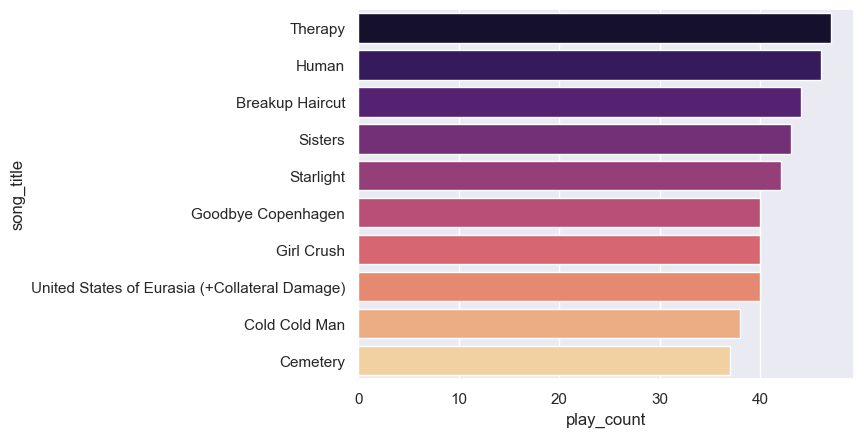

In [21]:
# print a bar plot including the top 10 tracks of 2020
sns.barplot(x="play_count", y="song_title", data=top_tracks_2020,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2020
top_tracks_2020_anagram = top_tracks_2020.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2020_anagram.head(10)

,artist_name,play count
0,Muse,551
1,One Direction,327
2,Blue October,315
3,New Politics,256
4,Bleachers,227
5,COIN,141
6,Saint Motel,121
7,My Chemical Romance,104
8,Chapel,101
9,YUNGBLUD,97


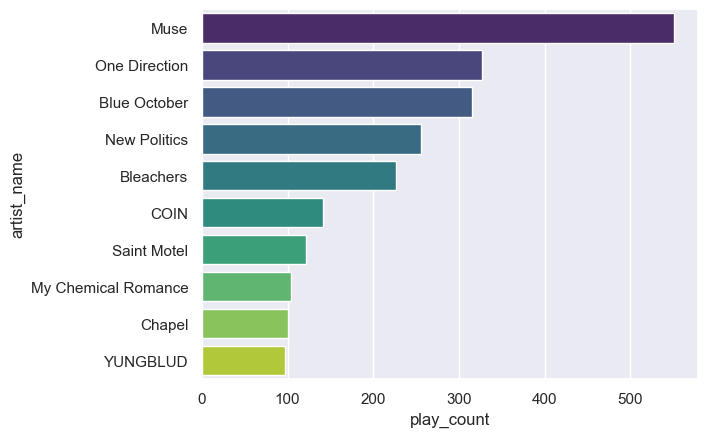

In [22]:
# print a bar plot including the top 10 artists of 2020
sns.barplot(x="play_count", y="artist_name", data=top_artists_2020,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2020
top_artists_2020_anagram = top_artists_2020.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2020_anagram.head(10)

## 2021

In [23]:
print(
    "======================================================================\n"
    "In 2021, you've enjoyed music for a total of", minutes_2021, "minutes, or", hours_2021, "hours.\n"
    "======================================================================"
)

In 2021, you've enjoyed music for a total of 21873 minutes, or 364 hours.


,song_title,album_name,play_count,artist
0,Bullet for Your Sweetheart,Visions of Hollywood,42,Make Out Monday
1,Potential Breakup Song,Potential Breakup Song,37,Aly & AJ
2,Revolt,Drones,37,Muse
3,Bulletproof Heart,Danger Days: The True Lives of the Fabulous Ki...,35,My Chemical Romance
4,On Melancholy Hill,Plastic Beach,34,Gorillaz
5,Creep,Pablo Honey,34,Radiohead
6,Uprising,The Resistance,33,Muse
7,Disenchanted,The Black Parade,33,My Chemical Romance
8,Reapers,Drones,33,Muse
9,The Night We Met,Strange Trails,32,Lord Huron


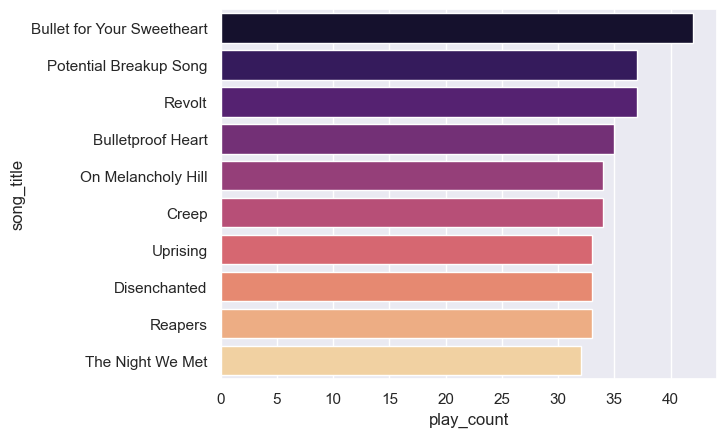

In [24]:
# print a bar plot including the top 10 tracks of 2021
sns.barplot(x="play_count", y="song_title", data=top_tracks_2021,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2021
top_tracks_2021_anagram = top_tracks_2021.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2021_anagram.head(10)

,artist_name,play count
0,My Chemical Romance,447
1,Muse,446
2,One Direction,225
3,Mother Mother,142
4,Neon Trees,140
5,Blue October,139
6,Bleachers,122
7,ConcernedApe,105
8,Lorde,96
9,Rise Against,95


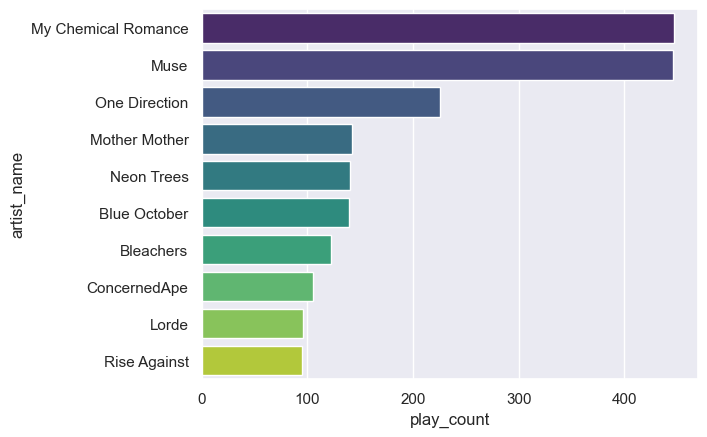

In [25]:
# print a bar plot including the top 10 artists of 2021
sns.barplot(x="play_count", y="artist_name", data=top_artists_2021,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2021
top_artists_2021_anagram = top_artists_2021.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2021_anagram.head(10)

## 2022

In [26]:
print(
    "======================================================================\n"
    "In 2022, you've enjoyed music for a total of", minutes_2022, "minutes, or", hours_2022, "hours.\n"
    "======================================================================"
)

In 2022, you've enjoyed music for a total of 27367 minutes, or 456 hours.


,song_title,album_name,play_count,artist
0,Call Me Little Sunshine,IMPERA,45,Ghost
1,Pressure,Simulation Theory,42,Muse
2,Pleasure,Feels Like We’ve Been Here Before,40,Betcha
3,Jenny Was A Friend Of Mine,Hot Fuss,39,The Killers
4,Revolt,Drones,38,Muse
5,Houdini,Torches,37,Foster The People
6,You Make Me Feel Like It’s Halloween,Will Of The People,35,Muse
7,Deus In Absentia,Meliora,33,Ghost
8,Neon Tiger,Day & Age - Bonus Tracks,33,The Killers
9,Swim Naked,Falling,33,Betcha


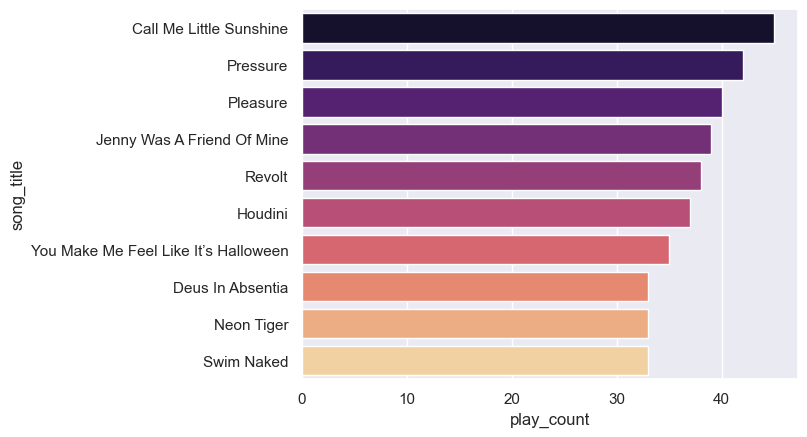

In [27]:
# print a bar plot including the top 10 tracks of 2022
sns.barplot(x="play_count", y="song_title", data=top_tracks_2022,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2022
top_tracks_2022_anagram = top_tracks_2022.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2022_anagram.head(10)

,artist_name,play count
0,Muse,798
1,Ghost,426
2,One Direction,274
3,My Chemical Romance,264
4,flipturn,224
5,The Killers,181
6,Mother Mother,171
7,Betcha,163
8,Bleachers,136
9,Blue October,129


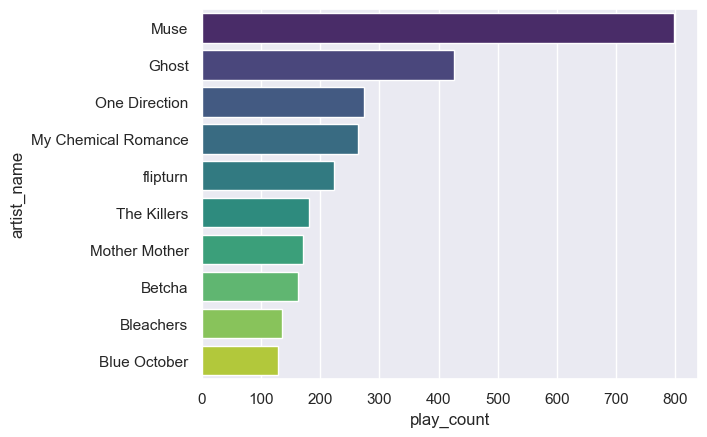

In [28]:
# print a bar plot including the top 10 artists of 2022
sns.barplot(x="play_count", y="artist_name", data=top_artists_2022,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2022
top_artists_2022_anagram = top_artists_2022.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2022_anagram.head(10)

## 2023

In [29]:
print(
    "======================================================================\n"
    "In 2023, you've enjoyed music for a total of", minutes_2023, "minutes, or", hours_2023, "hours.\n"
    "======================================================================"
)

In 2023, you've enjoyed music for a total of 16882 minutes, or 281 hours.


,song_title,album_name,play_count,artist
0,Thunderstruck,The Razors Edge,46,AC/DC
1,Enjoy the Silence - 2006 Remaster,Violator,43,Depeche Mode
2,Darkness At The Heart Of My Love,IMPERA,42,Ghost
3,Plug in Baby,Origin of Symmetry,35,Muse
4,Faith,Prequelle,33,Ghost
5,Cliffs Of Dover - Instrumental,Ah Via Musicom,30,Eric Johnson
6,Cirice,Meliora,30,Ghost
7,My Girlfriend's Girlfriend,October Rust,29,Type O Negative
8,You Shook Me All Night Long,Back In Black,29,AC/DC
9,1983,Habits,27,Neon Trees


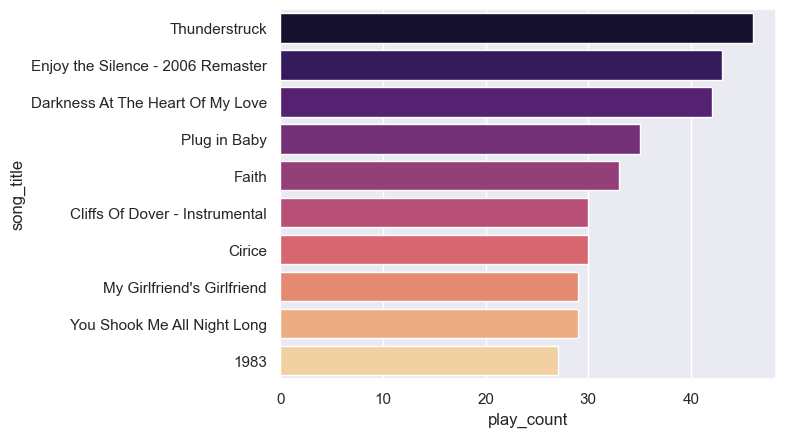

In [30]:
# print a bar plot including the top 10 tracks of 2023
sns.barplot(x="play_count", y="song_title", data=top_tracks_2023,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2023
top_tracks_2023_anagram = top_tracks_2023.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2023_anagram.head(10)

,artist_name,play count
0,Ghost,434
1,Muse,428
2,Neon Trees,180
3,The Killers,133
4,My Chemical Romance,110
5,Type O Negative,105
6,Mitski,99
7,Nuovo Testamento,88
8,AC/DC,87
9,Bleachers,83


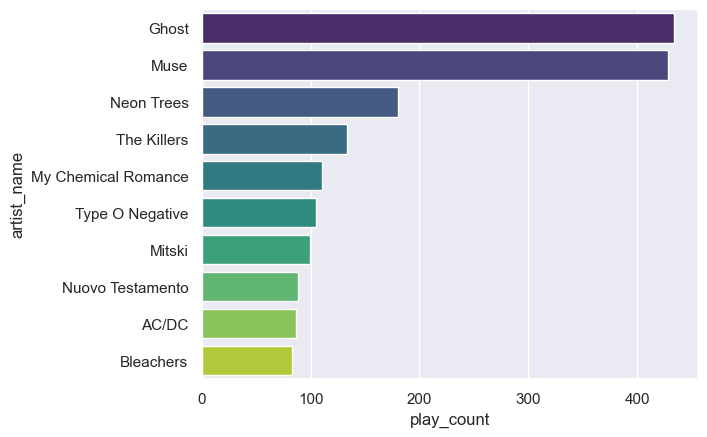

In [31]:
# print a bar plot including the top 10 artists of 2023
sns.barplot(x="play_count", y="artist_name", data=top_artists_2023,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2023
top_artists_2023_anagram = top_artists_2023.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2023_anagram.head(10)

## 2024

In [32]:
print(
    "======================================================================\n"
    "In 2024, you've enjoyed music for a total of", minutes_2024, "minutes, or", hours_2024, "hours.\n"
    "======================================================================"
)

In 2024, you've enjoyed music for a total of 21031 minutes, or 350 hours.


,song_title,album_name,play_count,artist
0,Silver,Wonderland,45,Nosferatu
1,Red Wine Supernova,The Rise and Fall of a Midwest Princess,43,Chappell Roan
2,Lucretia My Reflection - Vinyl Version,Floodland,33,Sisters of Mercy
3,Black Planet,First and Last and Always,33,Sisters of Mercy
4,Pink Pony Club,The Rise and Fall of a Midwest Princess,32,Chappell Roan
5,Lullaby,Greatest Hits,32,The Cure
6,Here Comes Your Man,Doolittle,31,Pixies
7,Toxicity,Toxicity,31,System Of A Down
8,All I Need,In Rainbows,31,Radiohead
9,Boys Don't Cry - Single Version,Three Imaginary Boys,30,The Cure


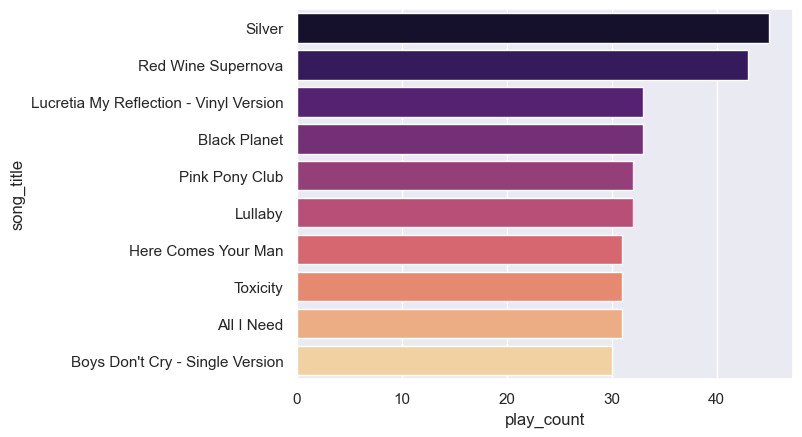

In [33]:
# print a bar plot including the top 10 tracks of 2024
sns.barplot(x="play_count", y="song_title", data=top_tracks_2024,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2024
top_tracks_2024_anagram = top_tracks_2024.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2024_anagram.head(10)

,artist_name,play count
0,Muse,406
1,Chappell Roan,304
2,Ghost,283
3,One Direction,210
4,The Cure,117
5,My Chemical Romance,113
6,Neon Trees,111
7,The Killers,109
8,Mitski,106
9,Nuovo Testamento,104


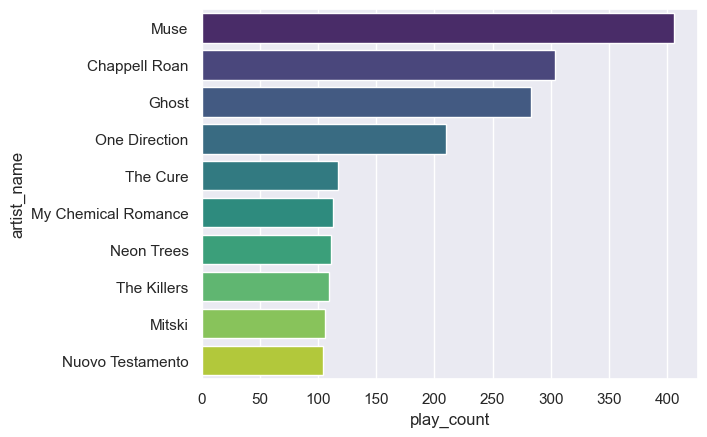

In [34]:
# print a bar plot including the top 10 artists of 2024
sns.barplot(x="play_count", y="artist_name", data=top_artists_2024,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2024
top_artists_2024_anagram = top_artists_2024.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2024_anagram.head(10)

## 2025

In [35]:
print(
    "======================================================================\n"
    "In 2025, you've enjoyed music for a total of", minutes_2025, "minutes, or", hours_2025, "hours.\n"
    "======================================================================"
)

In 2025, you've enjoyed music for a total of 19341 minutes, or 322 hours.


,song_title,album_name,play_count,artist
0,Pumping Iron,Starlight Express,30,Andrew Lloyd Webber
1,Vanish Into You,MAYHEM,26,Lady Gaga
2,Crimson and Clover,I Love Rock 'N' Roll (Expanded Edition),26,Joan Jett & the Blackhearts
3,Silver Springs - Live at Warner Brothers Studi...,The Dance,25,Fleetwood Mac
4,(One of Those) Crazy Girls,Paramore,25,Paramore
5,Rolling Stock,Starlight Express,25,Andrew Lloyd Webber
6,Perfect Celebrity,MAYHEM,24,Lady Gaga
7,Reapers,Drones,24,Muse
8,Umbra,Skeletá,23,Ghost
9,Zombieboy,MAYHEM,23,Lady Gaga


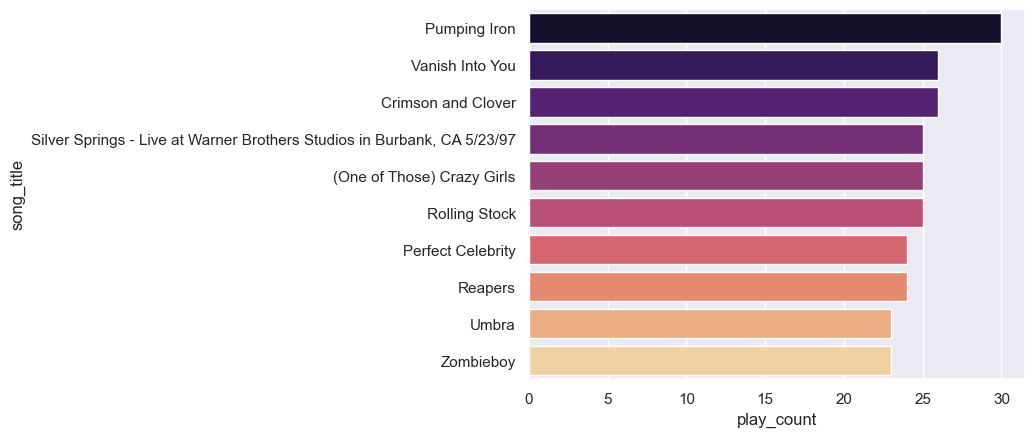

In [36]:
# print a bar plot including the top 10 tracks of 2025
sns.barplot(x="play_count", y="song_title", data=top_tracks_2025,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2025
top_tracks_2025_anagram = top_tracks_2025.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2025_anagram.head(10)

,artist_name,play count
0,Muse,385
1,Ghost,254
2,My Chemical Romance,234
3,Lady Gaga,164
4,Chappell Roan,138
5,Radiohead,104
6,Paramore,99
7,Toby Fox,79
8,The Killers,78
9,Weezer,73


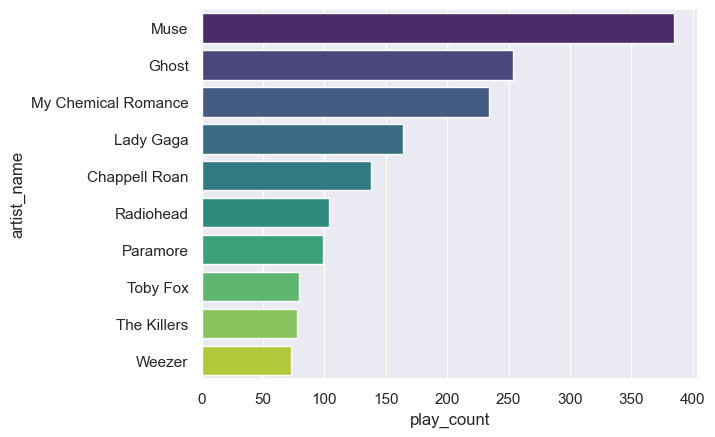

In [37]:
# print a bar plot including the top 10 artists of 2025
sns.barplot(x="play_count", y="artist_name", data=top_artists_2025,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2025
top_artists_2025_anagram = top_artists_2025.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2025_anagram.head(10)